# EEG & Spectrogram Data — EDA Overview

Loads a sample pair from the preprocessed `.npy` files in `/data_eeg_preprocessed/`  
and ties them back to `train_test_split.csv` to display:
- the **EEG id** and all 20 electrode channels
- the **spectrogram id** and its 4-region heatmap
- the **expert consensus** and raw **vote counts** for the labeled 50-second window

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
BASE         = os.path.abspath(os.path.join(os.getcwd(), "../.."))
EEG_NPY_DIR  = os.path.join(BASE, "data_eeg_preprocessed", "eeg_npy")
SPEC_NPY_DIR = os.path.join(BASE, "data_eeg_preprocessed", "spec_npy")
META_CSV     = os.path.join(BASE, "data_meta_splits", "train_test_split.csv")
RAW_SPEC_DIR = os.path.join(BASE, "data_raw", "train_spectrograms")

VOTE_COLS   = ["seizure_vote", "lpd_vote", "gpd_vote", "lrda_vote", "grda_vote", "other_vote"]
LABEL_NAMES = ["Seizure",      "LPD",      "GPD",      "LRDA",      "GRDA",      "Other"]
COLORS      = ["#e74c3c",      "#e67e22",  "#3498db",  "#2ecc71",  "#9b59b6",   "#95a5a6"]

print("BASE:", BASE)

BASE: /media/frank/Franknano/Python_Project/HMS_EEG


## 1 · Load metadata

In [3]:
meta = pd.read_csv(META_CSV)
print(f"Rows: {len(meta):,}  |  Columns: {list(meta.columns)}")
meta.head(3)

Rows: 106,800  |  Columns: ['eeg_id', 'eeg_sub_id', 'eeg_label_offset_seconds', 'spectrogram_id', 'spectrogram_sub_id', 'spectrogram_label_offset_seconds', 'label_id', 'patient_id', 'expert_consensus', 'seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote', 'label', 'split', 'inner_fold']


,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,label,split,inner_fold
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0,0,trainval,2
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0,0,trainval,2
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0,0,trainval,2


## 2 · Dataset summary statistics

In [4]:
splits = meta["split"].value_counts().to_dict()

summary_rows = [
    ("Unique patients",               meta["patient_id"].nunique(),        "-"),
    ("Unique EEG recordings",         meta["eeg_id"].nunique(),            "-"),
    ("Unique spectrogram recordings", meta["spectrogram_id"].nunique(),    "-"),
    ("Total labeled windows",         len(meta),                           len(meta)),
]
for sp, cnt in sorted(splits.items()):
    summary_rows.append((f"  — split: {sp}", cnt, cnt))

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "EEG", "Spectrogram"])
summary_df = summary_df.set_index("Metric")

# Avg sub-windows per unique recording
avg_eeg_windows  = len(meta) / meta["eeg_id"].nunique()
avg_spec_windows = len(meta) / meta["spectrogram_id"].nunique()

print("─" * 55)
print(summary_df.to_string())
print("─" * 55)
print(f"Avg labeled windows per EEG recording  : {avg_eeg_windows:.1f}")
print(f"Avg labeled windows per spectrogram    : {avg_spec_windows:.1f}")
print("─" * 55)
summary_df

───────────────────────────────────────────────────────
                                  EEG Spectrogram
Metric                                           
Unique patients                  1950           -
Unique EEG recordings           17089           -
Unique spectrogram recordings   11138           -
Total labeled windows          106800      106800
  — split: test                 23370       23370
  — split: trainval             83430       83430
───────────────────────────────────────────────────────
Avg labeled windows per EEG recording  : 6.2
Avg labeled windows per spectrogram    : 9.6
───────────────────────────────────────────────────────


,EEG,Spectrogram
Metric,,
Unique patients,1950,-
Unique EEG recordings,17089,-
Unique spectrogram recordings,11138,-
Total labeled windows,106800,106800
— split: test,23370,23370
— split: trainval,83430,83430


## 3 · Vote concentration — high vs low consensus

For each labeled window the 6 experts cast votes across categories.  
**High consensus** → the top category receives **> 10** votes (clear agreement).  
**Low consensus**  → the top category receives **< 10** votes (ambiguous label).

In [5]:
HIGH_THRESH = 10

max_vote   = meta[VOTE_COLS].max(axis=1)   # highest single-category vote per window
total_vote = meta[VOTE_COLS].sum(axis=1)   # total votes cast per window

high_mask   = max_vote >  HIGH_THRESH
low_mask    = max_vote <  HIGH_THRESH
border_mask = max_vote == HIGH_THRESH

n_total  = len(meta)
n_high   = high_mask.sum()
n_low    = low_mask.sum()
n_border = border_mask.sum()

print(f"Total labeled windows       : {n_total:>8,}  (100.0%)")
print(f"High consensus (max > {HIGH_THRESH:2d})   : {n_high:>8,}  ({100*n_high/n_total:.1f}%)")
print(f"Low  consensus (max < {HIGH_THRESH:2d})   : {n_low:>8,}  ({100*n_low/n_total:.1f}%)")
print(f"Borderline     (max = {HIGH_THRESH:2d})   : {n_border:>8,}  ({100*n_border/n_total:.1f}%)")
print()
print(f"Median total votes per window : {total_vote.median():.0f}")
print(f"Mean   total votes per window : {total_vote.mean():.1f}")

Total labeled windows       :  106,800  (100.0%)
High consensus (max > 10)   :   15,864  (14.9%)
Low  consensus (max < 10)   :   86,524  (81.0%)
Borderline     (max = 10)   :    4,412  (4.1%)

Median total votes per window : 3
Mean   total votes per window : 7.3


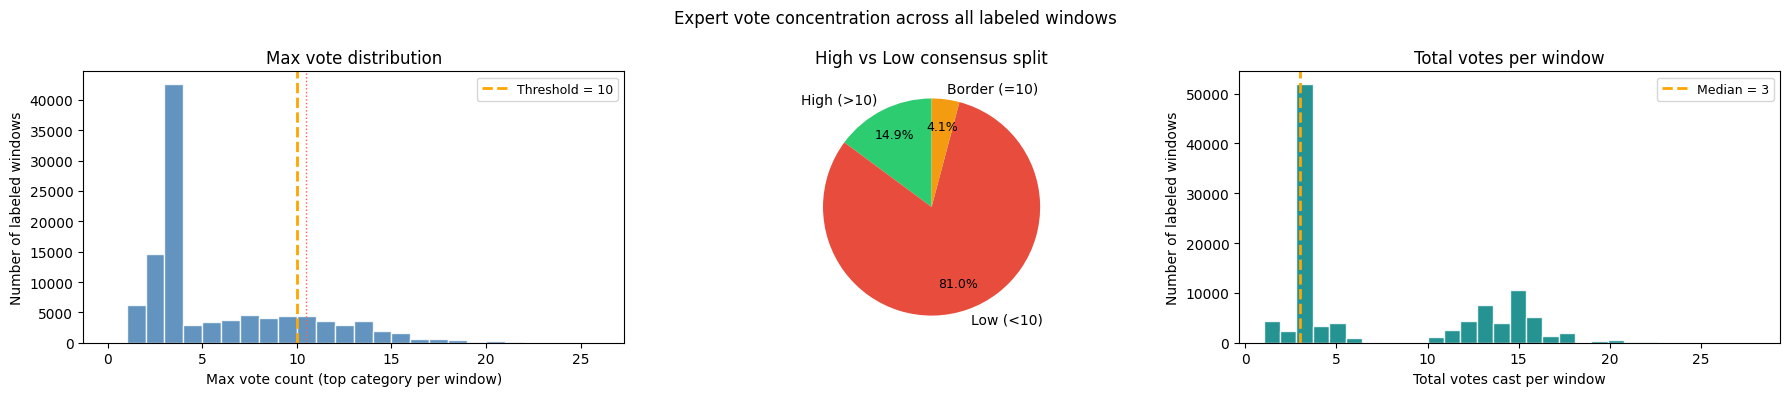

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Left: distribution of max single-category vote ───────────────────────────
ax = axes[0]
bins = range(0, int(max_vote.max()) + 2)
ax.hist(max_vote, bins=bins, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(HIGH_THRESH,       color="orange",  lw=2, ls="--", label=f"Threshold = {HIGH_THRESH}")
ax.axvline(HIGH_THRESH + 0.5, color="tomato",  lw=1, ls=":")
ax.set_xlabel("Max vote count (top category per window)")
ax.set_ylabel("Number of labeled windows")
ax.set_title("Max vote distribution")
ax.legend(fontsize=9)

# ── Middle: high / low / border breakdown ────────────────────────────────────
ax = axes[1]
labels_pie = [f"High (>{HIGH_THRESH})", f"Low (<{HIGH_THRESH})", f"Border (={HIGH_THRESH})"]
sizes_pie  = [n_high, n_low, n_border]
palette    = ["#2ecc71", "#e74c3c", "#f39c12"]
wedges, texts, autotexts = ax.pie(
    sizes_pie, labels=labels_pie, colors=palette,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("High vs Low consensus split")

# ── Right: total votes per window ────────────────────────────────────────────
ax = axes[2]
ax.hist(total_vote, bins=30, color="teal", edgecolor="white", alpha=0.85)
ax.axvline(total_vote.median(), color="orange", lw=2, ls="--",
           label=f"Median = {total_vote.median():.0f}")
ax.set_xlabel("Total votes cast per window")
ax.set_ylabel("Number of labeled windows")
ax.set_title("Total votes per window")
ax.legend(fontsize=9)

plt.suptitle("Expert vote concentration across all labeled windows", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Break down high-consensus windows by consensus class
high_by_class = (
    meta[high_mask]
    .groupby("expert_consensus")
    .size()
    .rename(f"high (>{HIGH_THRESH})")
)
low_by_class = (
    meta[low_mask]
    .groupby("expert_consensus")
    .size()
    .rename(f"low (<{HIGH_THRESH})")
)
consensus_breakdown = pd.concat([high_by_class, low_by_class], axis=1).fillna(0).astype(int)
consensus_breakdown["total"]   = consensus_breakdown.sum(axis=1)
consensus_breakdown["high_%"]  = (consensus_breakdown[f"high (>{HIGH_THRESH})"] / consensus_breakdown["total"] * 100).round(1)
consensus_breakdown

,high (>10),low (<10),total,high_%
expert_consensus,,,,
GPD,4490,10160,14650,30.6
GRDA,1494,16896,18390,8.1
LPD,3456,10771,14227,24.3
LRDA,1178,15170,16348,7.2
Other,5097,12797,17894,28.5
Seizure,149,20730,20879,0.7


## 4 · Expert consensus distribution — class balance

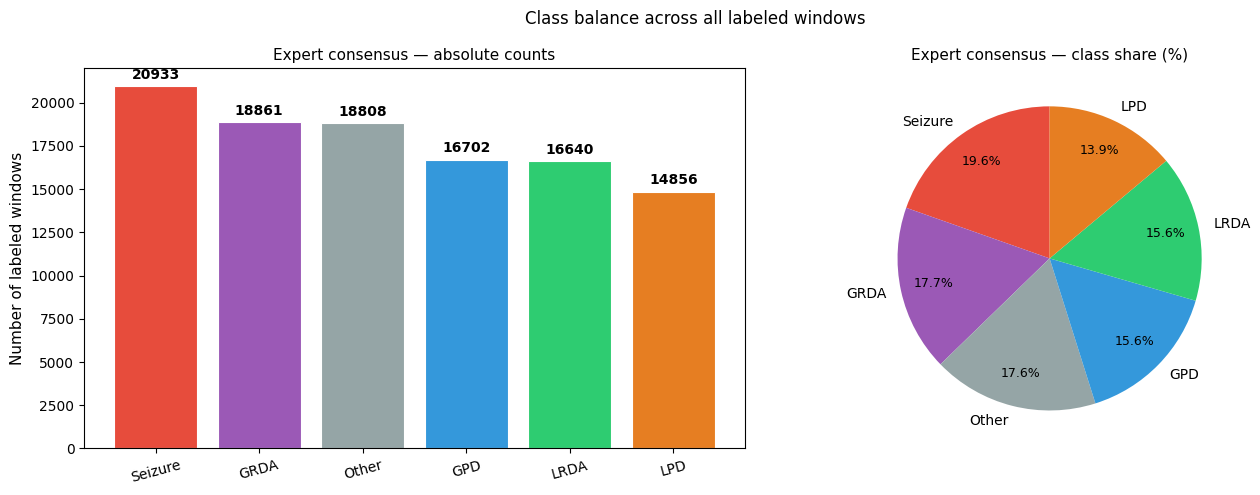

Most  common : Seizure    20,933  (19.6%)
Least common : LPD        14,856  (13.9%)
Imbalance ratio (max / min) : 1.4×


In [8]:
consensus_counts = meta["expert_consensus"].value_counts()
cls_names = consensus_counts.index.tolist()
cls_colors = [COLORS[LABEL_NAMES.index(c)] if c in LABEL_NAMES else "#aaaaaa" for c in cls_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: absolute bar chart ──────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(cls_names, consensus_counts.values, color=cls_colors, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10, fontweight="bold")
ax.set_ylabel("Number of labeled windows", fontsize=11)
ax.set_title("Expert consensus — absolute counts", fontsize=11)
ax.tick_params(axis="x", rotation=15)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Right: percentage pie ─────────────────────────────────────────────────────
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    consensus_counts.values,
    labels=cls_names,
    colors=cls_colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("Expert consensus — class share (%)", fontsize=11)

plt.suptitle("Class balance across all labeled windows", fontsize=12)
plt.tight_layout()
plt.show()

most_common  = consensus_counts.index[0]
least_common = consensus_counts.index[-1]
ratio        = consensus_counts.iloc[0] / consensus_counts.iloc[-1]
print(f"Most  common : {most_common:8s}  {consensus_counts.iloc[0]:>7,}  ({100*consensus_counts.iloc[0]/n_total:.1f}%)")
print(f"Least common : {least_common:8s}  {consensus_counts.iloc[-1]:>7,}  ({100*consensus_counts.iloc[-1]/n_total:.1f}%)")
print(f"Imbalance ratio (max / min) : {ratio:.1f}×")

## 5 · Find rows where both EEG and spec `.npy` files exist

In [9]:
eeg_npy_ids  = {os.path.splitext(f)[0] for f in os.listdir(EEG_NPY_DIR)  if f.endswith(".npy")}
spec_npy_ids = {os.path.splitext(f)[0] for f in os.listdir(SPEC_NPY_DIR) if f.endswith(".npy")}

valid = meta[
    meta["eeg_id"].astype(str).isin(eeg_npy_ids) &
    meta["spectrogram_id"].astype(str).isin(spec_npy_ids)
].copy()

print(f"Rows with both npy files: {len(valid):,} / {len(meta):,}")
print(f"Unique EEG IDs : {valid['eeg_id'].nunique():,}")
print(f"Unique spec IDs: {valid['spectrogram_id'].nunique():,}")
valid.groupby("expert_consensus").size().rename("count").to_frame()

Rows with both npy files: 106,800 / 106,800
Unique EEG IDs : 17,089
Unique spec IDs: 11,138


,count
expert_consensus,
GPD,16702
GRDA,18861
LPD,14856
LRDA,16640
Other,18808
Seizure,20933


## 6 · Select one representative sample per label class

In [10]:
# One representative per consensus class
sample_table = valid.groupby("expert_consensus").first().reset_index()
sample_table[["expert_consensus", "eeg_id", "spectrogram_id",
              "eeg_label_offset_seconds"] + VOTE_COLS]

,expert_consensus,eeg_id,spectrogram_id,eeg_label_offset_seconds,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,GPD,2277392603,924234,0.0,0,0,5,0,1,5
1,GRDA,2578018731,2207717,20.0,0,0,2,0,9,2
2,LPD,736446371,10397461,0.0,0,1,0,0,0,0
3,LRDA,722738444,999431,0.0,0,1,0,14,0,1
4,Other,1202099836,1353070,0.0,0,0,5,0,0,9
5,Seizure,1628180742,353733,0.0,3,0,0,0,0,0


In [11]:
# ─── Change ROW_IDX to pick a different class ───────────────────────────────
ROW_IDX = 0   # 0 = first class in sample_table above

row = sample_table.iloc[ROW_IDX]
eeg_id          = int(row["eeg_id"])
spec_id         = int(row["spectrogram_id"])
consensus       = row["expert_consensus"]
votes           = row[VOTE_COLS].values.astype(int)
eeg_offset_sec  = float(row["eeg_label_offset_seconds"])
spec_offset_sec = float(row["spectrogram_label_offset_seconds"])

print(f"EEG ID           : {eeg_id}")
print(f"Spectrogram ID   : {spec_id}")
print(f"Expert consensus : {consensus}")
print(f"EEG label offset : {eeg_offset_sec} s")
print(f"Spec label offset: {spec_offset_sec} s")
print("Votes  →  " + "  |  ".join(f"{n}: {v}" for n, v in zip(LABEL_NAMES, votes)))

EEG ID           : 2277392603
Spectrogram ID   : 924234
Expert consensus : GPD
EEG label offset : 0.0 s
Spec label offset: 0.0 s
Votes  →  Seizure: 0  |  LPD: 0  |  GPD: 5  |  LRDA: 0  |  GRDA: 1  |  Other: 5


## 7 · EEG time-series plot

In [12]:
EEG_CHANNELS = [
    "Fp1", "F3",  "C3",  "P3",  "F7",  "T3",  "T5",  "O1",
    "Fz",  "Cz",  "Pz",
    "Fp2", "F4",  "C4",  "P4",  "F8",  "T4",  "T6",  "O2",
    "EKG"
]
FS = 200          # Hz
WINDOW_SEC = 50   # labeled window duration

eeg = np.load(os.path.join(EEG_NPY_DIR, f"{eeg_id}.npy"))   # (N, 20)
n_samples, n_ch = eeg.shape
duration_sec    = n_samples / FS
time_eeg        = np.arange(n_samples) / FS

print(f"EEG shape : {eeg.shape}  ({duration_sec:.1f} s at {FS} Hz)")
print(f"NaN count : {np.isnan(eeg).sum()}")

EEG shape : (10400, 20)  (52.0 s at 200 Hz)
NaN count : 0


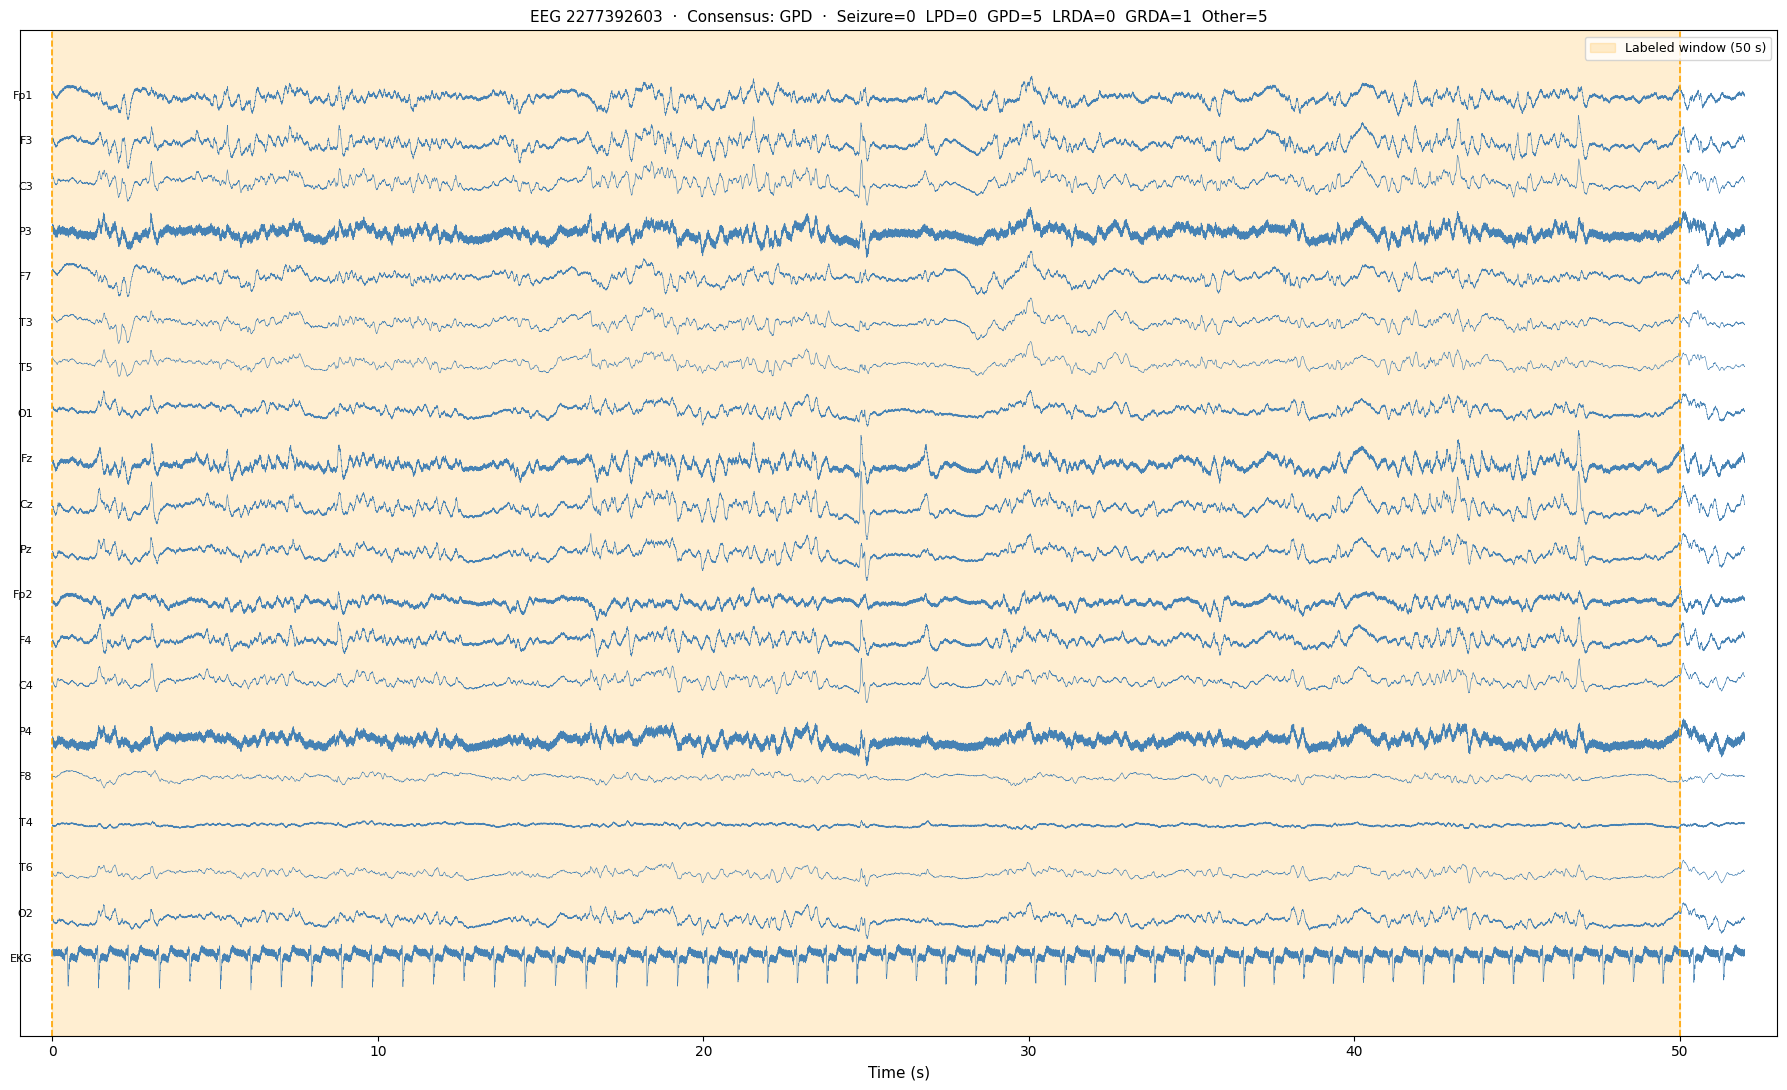

In [13]:
SCALE = 150  # µV separation between channels

fig, ax = plt.subplots(figsize=(18, 11))

for i, ch in enumerate(EEG_CHANNELS):
    offset = (n_ch - 1 - i) * SCALE
    sig = eeg[:, i]
    sig = np.clip(sig, -500, 500)
    ax.plot(time_eeg, sig + offset, lw=0.4, color="steelblue")
    ax.text(-0.6, offset, ch, ha="right", va="center", fontsize=8)

# Highlight the labeled 50-second window
ax.axvspan(eeg_offset_sec, eeg_offset_sec + WINDOW_SEC,
           color="orange", alpha=0.18, label="Labeled window (50 s)")
ax.axvline(eeg_offset_sec,              color="orange", lw=1.2, ls="--")
ax.axvline(eeg_offset_sec + WINDOW_SEC, color="orange", lw=1.2, ls="--")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_xlim(-1, duration_sec + 1)
ax.set_yticks([])
ax.set_title(
    f"EEG {eeg_id}  ·  Consensus: {consensus}  ·  "
    + "  ".join(f"{n}={v}" for n, v in zip(LABEL_NAMES, votes)),
    fontsize=11
)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 8 · Spectrogram heatmap

In [14]:
spec_npy = np.load(os.path.join(SPEC_NPY_DIR, f"{spec_id}.npy"))  # (T, 401)
n_time_rows, n_cols = spec_npy.shape

# Column 0 is the time axis (in seconds, every 2 s)
time_spec = spec_npy[:, 0]

# Get column names from the raw parquet (preserves exact naming & order)
ref_parquet = os.path.join(RAW_SPEC_DIR, f"{spec_id}.parquet")
if os.path.exists(ref_parquet):
    spec_cols = pd.read_parquet(ref_parquet).columns.tolist()
else:
    # Fallback: reconstruct names from known HMS format
    freqs = np.round(np.linspace(0.59, 19.92, 100), 2)
    spec_cols = ["time"]
    for reg in ["LL", "LP", "RP", "RL"]:
        spec_cols += [f"{reg}_{f}" for f in freqs]

# Group column indices by region prefix
region_cols = {}
for region in ["LL", "LP", "RP", "RL", "RR"]:
    idxs = [i for i, c in enumerate(spec_cols) if c.startswith(region + "_")]
    if idxs:
        region_cols[region] = idxs

print(f"Spec shape  : {spec_npy.shape}")
print(f"Time range  : {time_spec[0]:.0f} s – {time_spec[-1]:.0f} s")
print(f"Regions     : {list(region_cols.keys())}")

Spec shape  : (301, 401)
Time range  : 1 s – 601 s
Regions     : ['LL', 'LP', 'RP', 'RL']


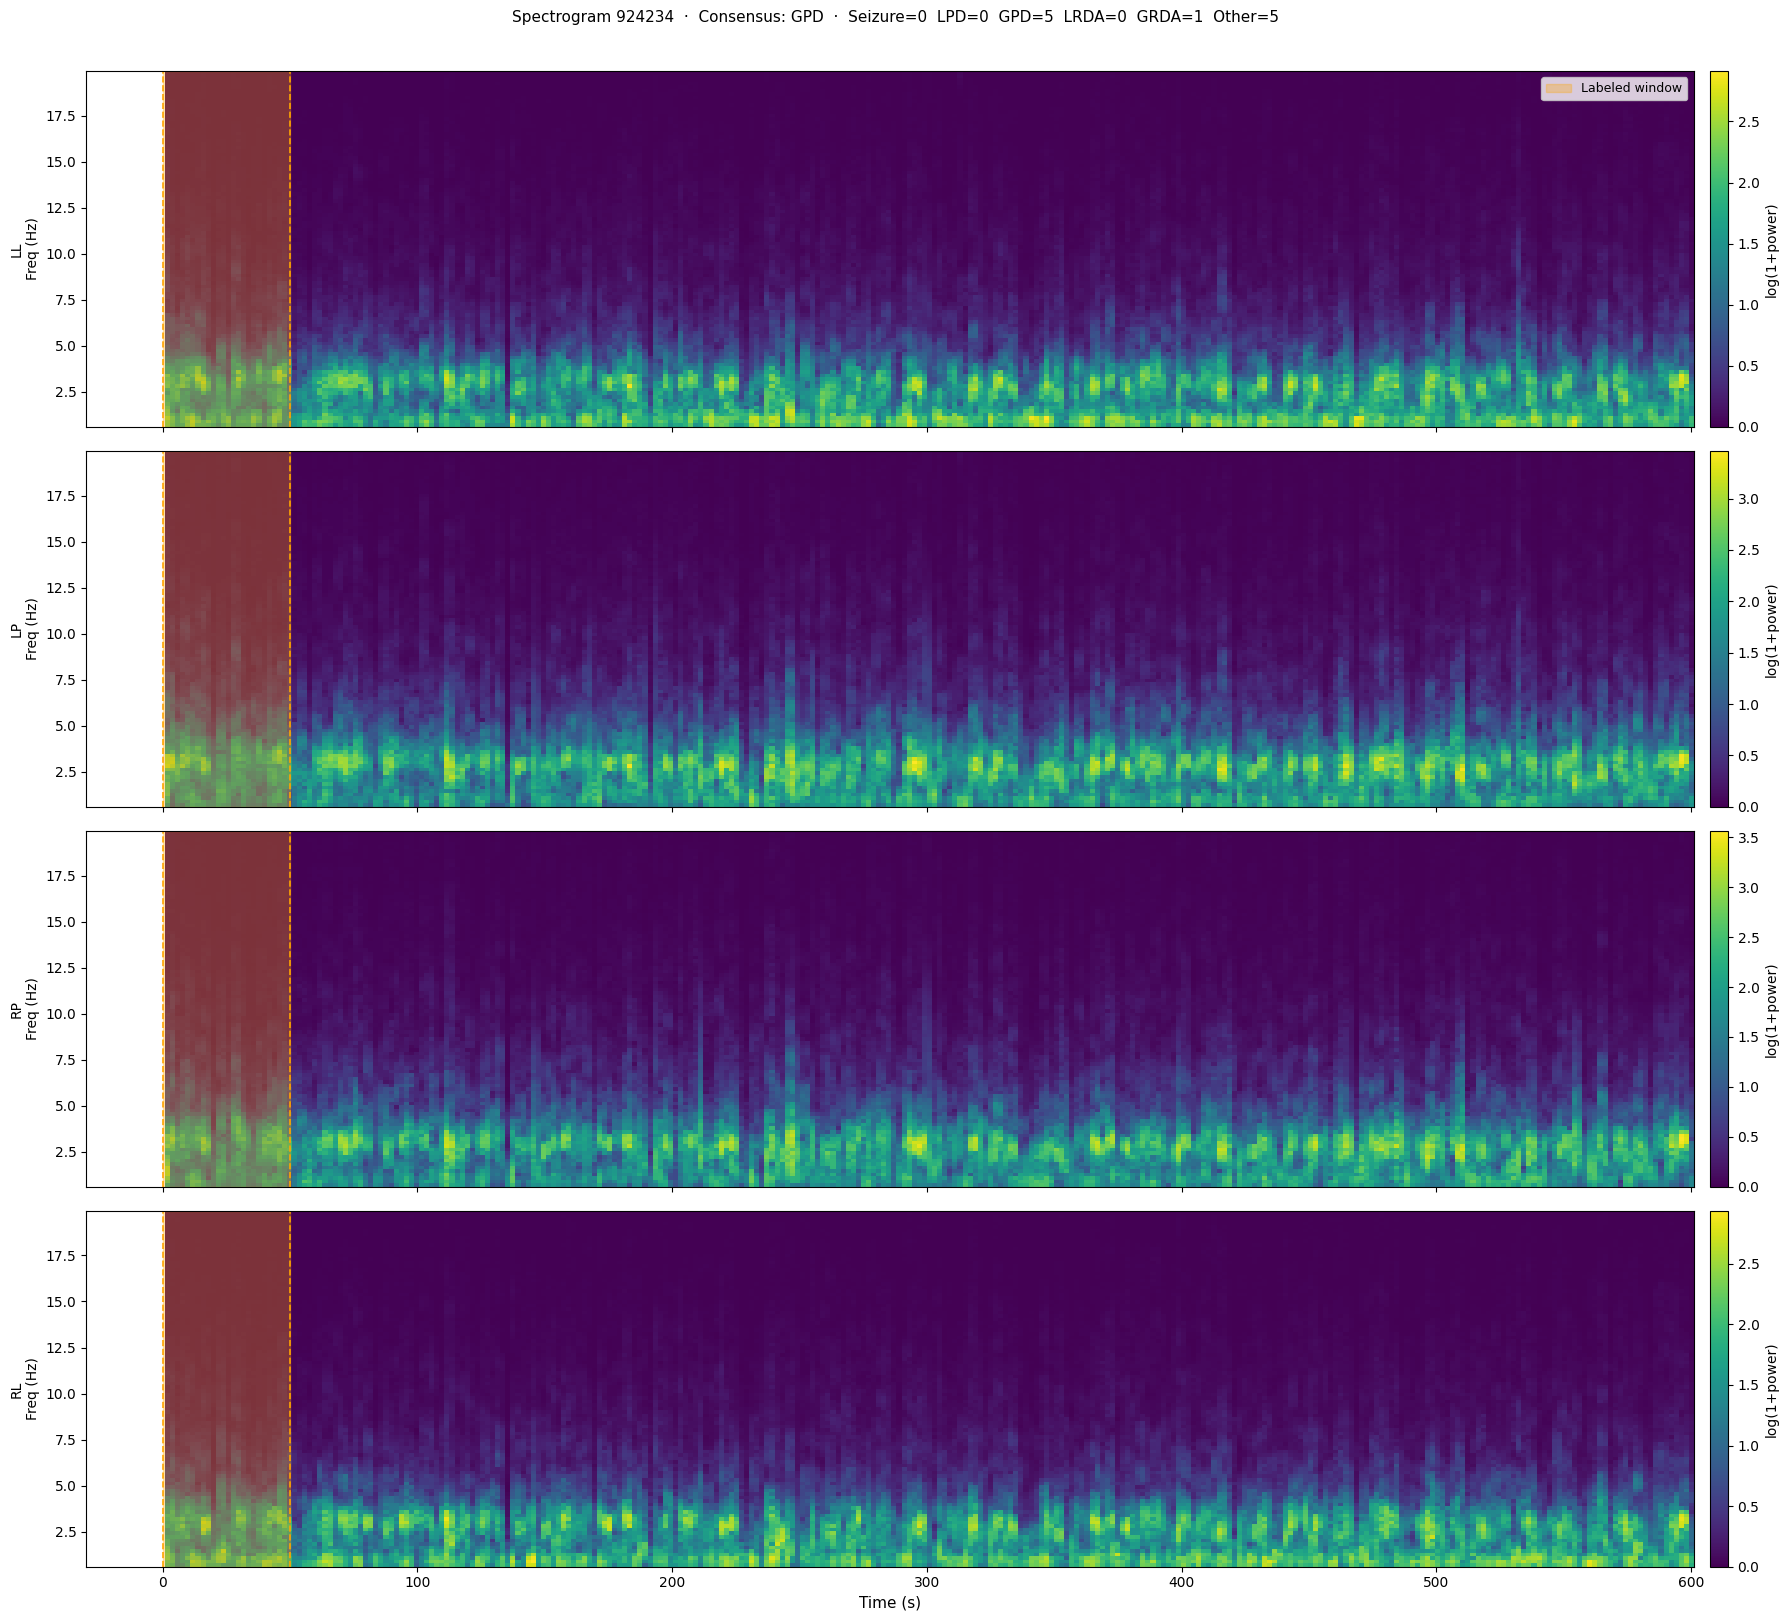

In [15]:
n_regions = len(region_cols)
fig, axes = plt.subplots(n_regions, 1, figsize=(18, 4 * n_regions), sharex=True)
if n_regions == 1:
    axes = [axes]

first_region = list(region_cols.keys())[0]
for ax, (region, col_idxs) in zip(axes, region_cols.items()):
    region_data = spec_npy[:, col_idxs]                    # (T, 100)
    freqs = np.array([float(spec_cols[i].split("_")[1]) for i in col_idxs])
    region_log  = np.log1p(np.clip(region_data, 0, None))  # log scale power

    im = ax.imshow(
        region_log.T,           # → (100_freq, T_time)
        aspect="auto",
        origin="lower",
        extent=[time_spec[0], time_spec[-1], freqs[0], freqs[-1]],
        cmap="viridis",
        interpolation="nearest"
    )

    # Highlight the labeled 50-second window
    ax.axvspan(spec_offset_sec, spec_offset_sec + WINDOW_SEC,
               color="orange", alpha=0.30,
               label="Labeled window" if region == first_region else "")
    ax.axvline(spec_offset_sec,              color="orange", lw=1.2, ls="--")
    ax.axvline(spec_offset_sec + WINDOW_SEC, color="orange", lw=1.2, ls="--")

    ax.set_ylabel(f"{region}\nFreq (Hz)", fontsize=10)
    plt.colorbar(im, ax=ax, label="log(1+power)", fraction=0.02, pad=0.01)
    if region == first_region:
        ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Time (s)", fontsize=11)
fig.suptitle(
    f"Spectrogram {spec_id}  ·  Consensus: {consensus}  ·  "
    + "  ".join(f"{n}={v}" for n, v in zip(LABEL_NAMES, votes)),
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

## 9 · Expert vote distribution (selected sample)

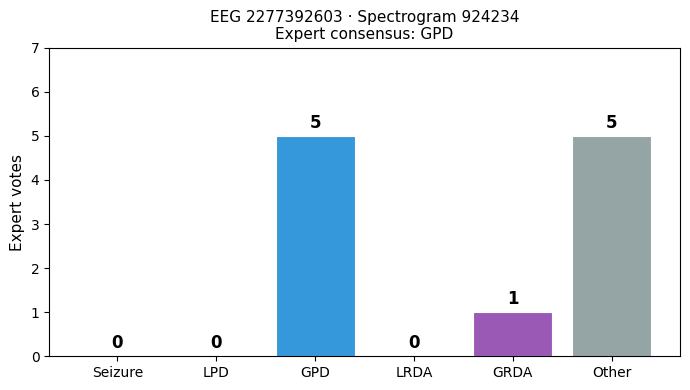

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(LABEL_NAMES, votes, color=COLORS, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=12, fontweight="bold")
ax.set_ylabel("Expert votes", fontsize=11)
ax.set_ylim(0, max(votes.max(), 1) + 2)
ax.set_title(
    f"EEG {eeg_id} · Spectrogram {spec_id}\n"
    f"Expert consensus: {consensus}",
    fontsize=11
)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 10 · Browse all label classes side by side

Plots a **zoomed-in 50-second labeled window** for every consensus class in one combined figure.

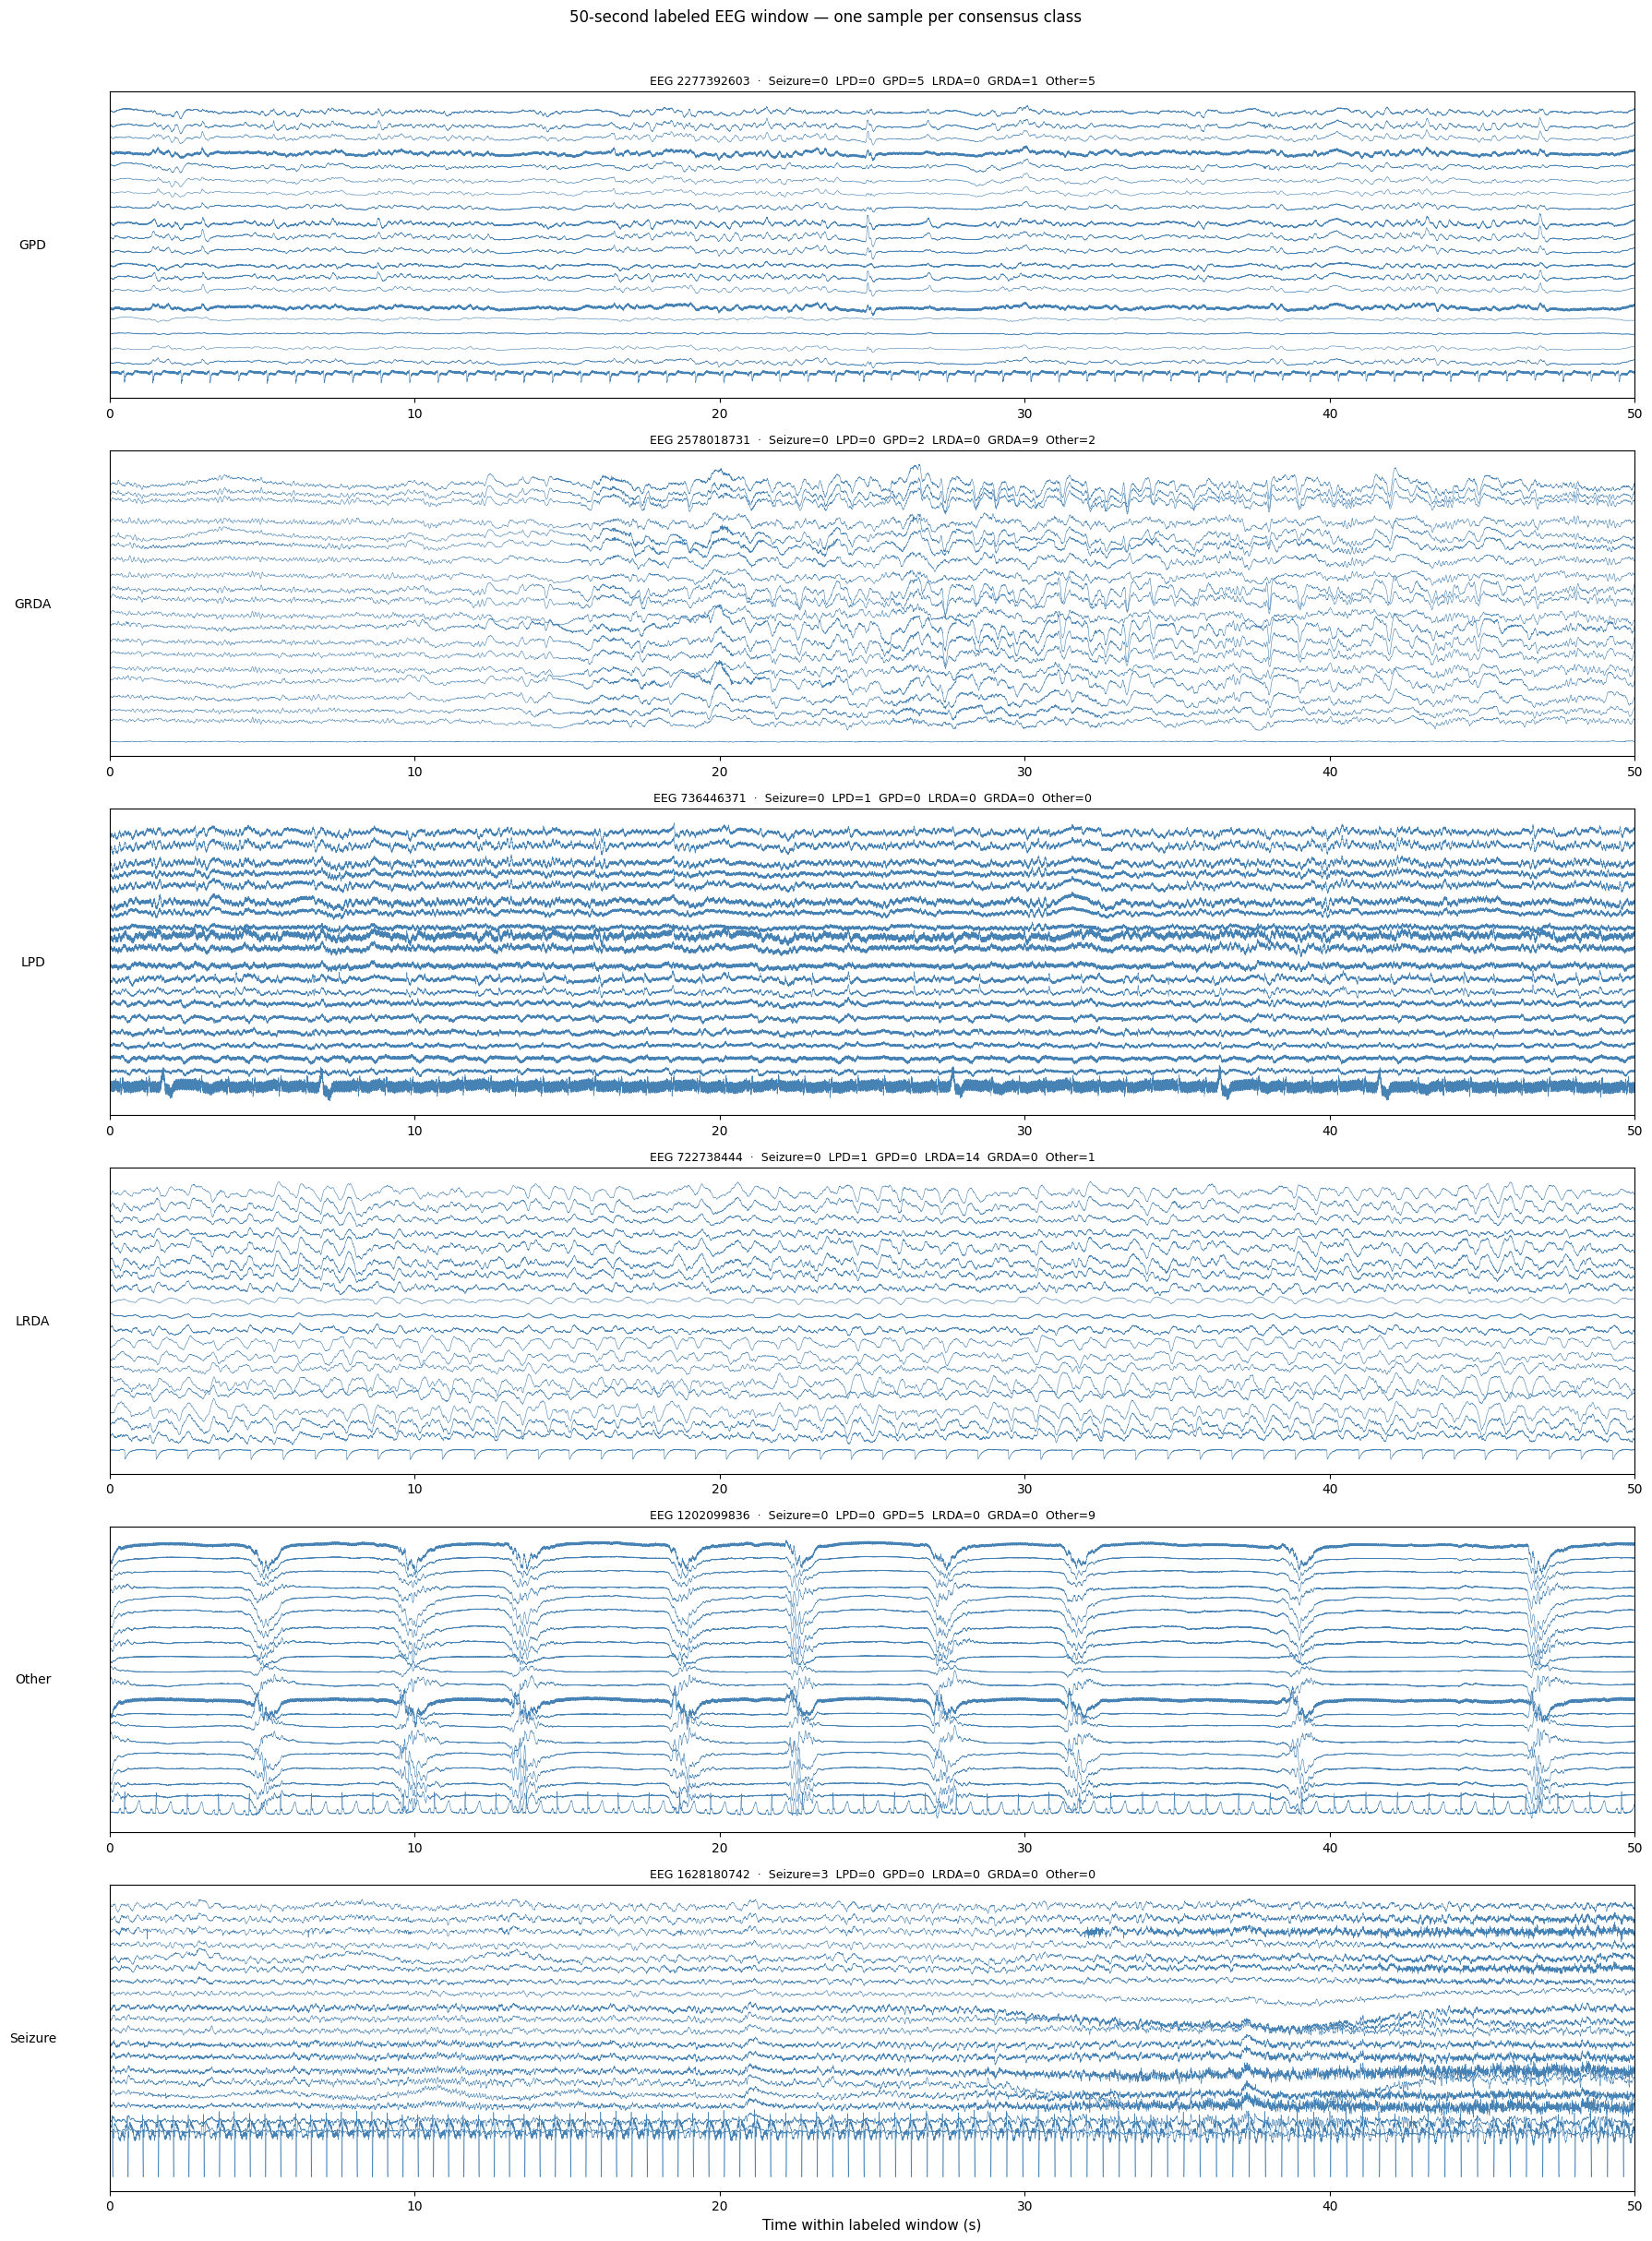

In [17]:
classes = sample_table["expert_consensus"].tolist()
n_cls   = len(classes)

fig, axes = plt.subplots(n_cls, 1, figsize=(18, 4 * n_cls), sharex=False)
if n_cls == 1:
    axes = [axes]

for ax, (_, srow) in zip(axes, sample_table.iterrows()):
    s_eeg_id    = int(srow["eeg_id"])
    s_consensus = srow["expert_consensus"]
    s_votes     = srow[VOTE_COLS].values.astype(int)
    s_offset    = float(srow["eeg_label_offset_seconds"])

    s_eeg = np.load(os.path.join(EEG_NPY_DIR, f"{s_eeg_id}.npy"))
    s_N   = s_eeg.shape[0]

    # Extract the 50-second labeled window
    start_idx = int(s_offset * FS)
    end_idx   = min(start_idx + WINDOW_SEC * FS, s_N)
    window    = s_eeg[start_idx:end_idx, :]
    t_win     = np.arange(len(window)) / FS

    for i, ch in enumerate(EEG_CHANNELS):
        offset = (n_ch - 1 - i) * SCALE
        sig = np.clip(window[:, i], -500, 500)
        ax.plot(t_win, sig + offset, lw=0.4, color="steelblue")

    ax.set_yticks([])
    ax.set_xlim(0, WINDOW_SEC)
    ax.set_ylabel(s_consensus, fontsize=10, rotation=0, labelpad=60, va="center")
    vote_str = "  ".join(f"{n}={v}" for n, v in zip(LABEL_NAMES, s_votes))
    ax.set_title(f"EEG {s_eeg_id}  ·  {vote_str}", fontsize=9)

axes[-1].set_xlabel("Time within labeled window (s)", fontsize=11)
fig.suptitle("50-second labeled EEG window — one sample per consensus class",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()